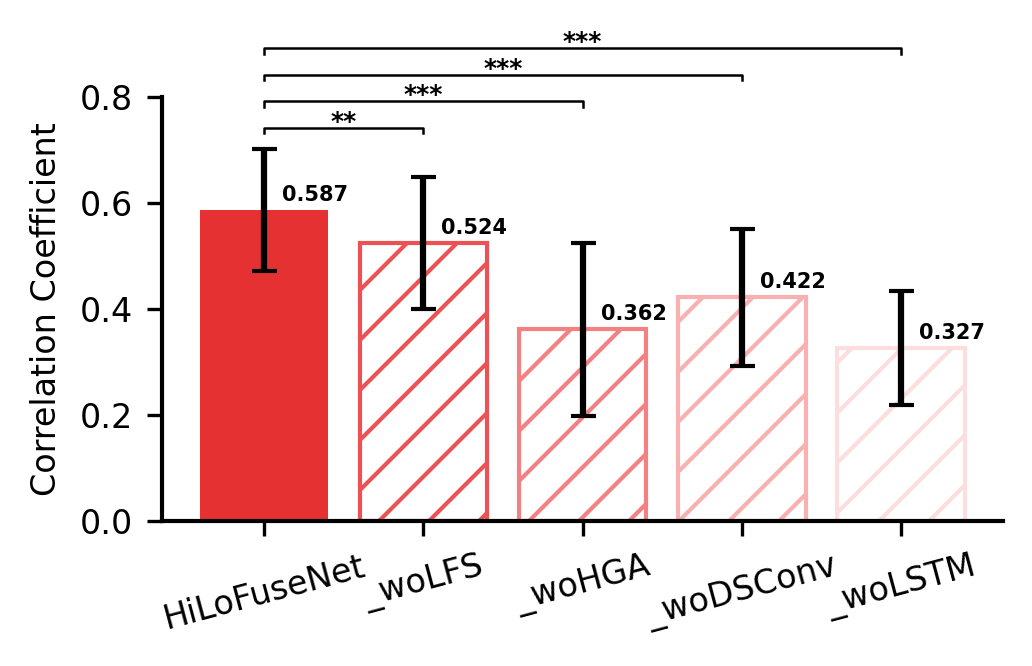

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

win_size = 2.8
seed = 42
datasets = ['BCIIV', 'Stanford']
decoders = ['HiLoFuseNet', 'HiLoFuseNet_HGA', 'HiLoFuseNet_LFS', 'HiLoFuseNet_woDSConv', 'HiLoFuseNet_woLSTM']
decoder_names = ['HiLoFuseNet', '_woLFS', '_woHGA', '_woDSConv', '_woLSTM']

all_decoder_means = []
all_decoder_stds = []
all_decoder_pools = []

for decoder in decoders:
    decoder_cc_pool = []

    for dataset in datasets:
        file_path = f'results/o5/ablation/{dataset}_{decoder}_mse_seed{seed}_win{win_size}_o5_cc.npy'

        if os.path.exists(file_path):
            try:
                cc_data = np.load(file_path)
                subject_means = np.mean(cc_data, axis=0)
                decoder_cc_pool.extend(subject_means)
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
        else:
            print(f"Warning: File not found -> {file_path}")

    if decoder_cc_pool:
        all_decoder_means.append(np.mean(decoder_cc_pool))
        all_decoder_stds.append(np.std(decoder_cc_pool))
        all_decoder_pools.append(decoder_cc_pool)
    else:
        all_decoder_means.append(0)
        all_decoder_stds.append(0)
        all_decoder_pools.append([])
        print(f"No data found for decoder: {decoder}")

p_values = []
compare_pairs = []
if len(all_decoder_pools) > 1 and len(all_decoder_pools[0]) > 0:
    for i in range(1, len(all_decoder_pools)):
        if len(all_decoder_pools[i]) == len(all_decoder_pools[0]):
            # Wilcoxon
            _, p_val = wilcoxon(all_decoder_pools[0], all_decoder_pools[i])
            p_values.append(p_val)
            compare_pairs.append((0, i))

    # FDR correction
    if p_values:
        reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
    else:
        p_corrected = []
else:
    p_corrected = []

# visualization
cm = 1 / 2.54
fig, ax = plt.subplots(figsize=(9 * cm, 6 * cm), dpi=300)

colors = ['#E31A1C', '#EC5254', '#F38183', '#F9B0B1', '#FCDEDE']
bars = ax.bar(
    decoder_names,
    all_decoder_means,
    yerr=all_decoder_stds,
    capsize=3,
    zorder=1
)
bars[0].set_facecolor(colors[0])
bars[0].set_edgecolor('none')
bars[0].set_linewidth(0)
bars[0].set_alpha(0.9)

for i in range(1, 5):
    bars[i].set_hatch('//')
    bars[i].set_facecolor('white')
    bars[i].set_edgecolor(colors[i])
    bars[i].set_linewidth(1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2*1.8,
            yval + 0.01,
            f"{yval:.3f}",
            ha='center',
            va='bottom',
            color='black',
            fontsize=5,
            fontweight='bold'
        )

# mark significance
if len(p_corrected) > 0:
    base_y = max([m + s for m, s in zip(all_decoder_means, all_decoder_stds)]) + 0.04
    step_y = 0.05

    for idx, (idx0, idx1) in enumerate(compare_pairs):
        p_ann = p_corrected[idx]
        if p_ann < 0.05:
            if p_ann < 0.001:
                mark = '***'
            elif p_ann < 0.01:
                mark = '**'
            else:
                mark = '*'

            y_line = base_y + idx * step_y
            x0, x1 = idx0, idx1

            ax.plot([x0, x0, x1, x1], [y_line - 0.01, y_line, y_line, y_line - 0.01],
                    color='black', linewidth=0.6, zorder=4, clip_on=False)
            ax.text((x0 + x1) / 2, y_line-0.01, mark, ha='center', va='bottom',
                    color='black', fontsize=6, fontweight='bold',clip_on=False)

ax.set_ylabel('Correlation Coefficient', fontsize=8)
ax.tick_params(axis='both', labelsize=8, direction='out')
plt.xticks(rotation=15, ha='center')
ax.set_ylim(0, 0.8)

plt.tight_layout()
figPath = 'E:/my papers/finger decoding/HiLoFuseNet/manuscript/figures/'
plt.savefig(figPath+"ablation.png", dpi=300)
plt.show()